Telco Customer Churn
---

    - Chosen dataset:
A dataset that was released by IBM Sample Data Sets, on the customers of a telecommunications company (Telco). The dataset contains various information on the customers, examples being their gender, payment methods, and many more. Additionally, it provides the information on whether or not the customer discontinued the given service, or in other words churned, within a month.

    - Business problem:
To what extent can Telco predict whether a customer will cancel their service, based on the information given on the customers?

    - Why is it important?:
Marketing uses a lot of resources to acquire more new customers, hence showing that customer acquisition is not only very important but also quite expensive. Whenever a company is on the verge of losing a customer perks, such as bonus discounts, get blindly assigned to everyone. This wastes a lot of money, as some might have not left in the first place or there might be some customers who were going to leave no matter what. 
Instead these resources could be used on customers who actually need this intervention and be the focus of retention efforts. This highlights the importance of identifying the churn of customers, as a company can step in before potentially losing a customer, hence keeping their clientele.

    - Benefits:
Being able to identify the churn rate of customers is very significant, as that way, marketing would know where to delegate its resources more effectively.
On top of that, having these data driven insights would allow the company to better prepare and tackle the issue of customers leaving. Instead of only focusing on separate clients, the company could work on improving the underlying pricing strategy or anything else that could be causing this issue of churn in the first place.

    - How will we know if its beneficial or not?
To test out if it was actually beneficial or not, the company's churn rate before the retention methods that were modified based on the data collected by the model and after. So the database would be constantly updated and the results would be compared. Depending on whether or not these new strategies lead to a decrease in churn rate or not would show if the model ended up being useful. 


    - How is the relevant data being collected?
For this assignment, I am using an already existing dataset provided by IBM. 
In an actual setting, the company would first start by collecting the information regarding the bills. The details of the each customer as well as other features such as the details of the contract, would be collected to replicate the information that is in the dataset that I am utilizing.
Carrying on, the churn status of each client would also automatically be recorded whenever a person cancels the service. This would allow for a passive form of data collection that updates continuously without the need of direct intervention.

    - Formulating this problem as a machine learning task:
This problem uses the idea of a binary classification task.
The dataset is broken down in a way where the information regarding a customer, such as their account details, is separated into rows. The target variable of this problem is Churn, where if a customer left within the last month they are labeled as 'Yes' and if not, then they have the 'No' label. The model learns the relationships between the various charateristics of the customer and the possibility of them discountinuing the service. This way a prediction is created for future new customers. 
Instead of relying on the vague idea of 'customer loyalty', the model focuses on creating a concrete prediction, which can be used later by the company to improve their marketing techniques and flag down customers that are highly likely to churn.

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('telco.csv')

---
Data Exploration: Overlooking Everything
---

In [42]:
print(df.shape) 
#Shows that there are 7043 rows and 21 columns.

(7043, 21)


In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df.describe().T[['mean', 'std', 'min', 'max']].head()

,mean,std,min,max
SeniorCitizen,0.162147,0.368612,0.00,1.00
tenure,32.371149,24.559481,0.00,72.00
MonthlyCharges,64.761692,30.090047,18.25,118.75


In [45]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [46]:
print("Throughout the dataset, there are", df.duplicated().sum(), "duplicate rows.")

Throughout the dataset, there are 0 duplicate rows.


---
Data Exploration: Splitting Data
---

In [47]:
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Churn']
)
#By adding stratify, the proportion of churned customers in both the training and test sets is maintained.

print('Training set shape:', train_df.shape)
print('Test set shape:', test_df.shape)

Training set shape: (5634, 21)
Test set shape: (1409, 21)


    - Splitting:
To ensure that there is no data leakage and that both training and test data get evaluated by themselves, a random 80/20 split was applied. By adding the stratify argument into the split, it makes sure that both of the sets have the same proportions of churned or not churned customers when compared to the original data set. That way the possibility of one of the sets being randomly skewed is removed as an issue.

---
Data Exploration: Data Types
---

In [48]:
df.dtypes 
#To understand which data types the dataset contains

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [49]:
#TotalCharges is said to be a string, but it should instead be a numerical value.

train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
#By adding the errors argument, any values that cannot be turned into a numerical value will instead be replaced with NaN.

print(train_df['TotalCharges'].dtype)
print('Missing TotalCharges:', train_df['TotalCharges'].isna().sum())
#Thanks to the coerce argument, we can now see that there were 8 missing values.

float64
Missing TotalCharges: 8


    - Data Types: 
It can be seen that although most of the columns are categorical, there are a few that were numerical. After a careful examnination, it was found out that there was only one column that had a misleading data type: TotalCharges. Despite containing numerical values, it was stored as the string type. After being changed to the numeric type, a few missing values, that were previously undetected as they were hidden as blank strings, were discovered.

---
Data Exploration: Finding Explicit Missing Values
---

In [50]:
train_df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
Churn               0
dtype: int64

    - Missing Values:
In the raw data set, no missing values (or NaN) were found except from the ones that was revealed after the conversion of TotalCharges. During a check of implicit missing values, a few tenure values were found to be equal to 0. However, after a closer inspection it was found out that these values were normal and just suggested that the customer was new.

---
Data Exploration: Finding Implicit Missing Values
---

In [51]:
#Checking categorical columns and if they have weird/unknown values

categorical_columns = ['gender','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies','Contract',
            'PaperlessBilling','PaymentMethod','Churn']
for col in categorical_columns:
    print(col, ':', train_df[col].unique())

#So it goes through all of the categorical columns and prints out the unique values.

gender : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Partner : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Contract : <StringArray>
['Month-to-month', 

In [52]:
#A check for hidden, blank or whitespace in columns that have strings.

text_cols = train_df.select_dtypes(include='object').columns
for col in text_cols:
    empty_count = (train_df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(col, 'has', empty_count, 'blank values')
    else:
        print(col, 'has no blank values')

customerID has no blank values
gender has no blank values
Partner has no blank values
Dependents has no blank values
PhoneService has no blank values
MultipleLines has no blank values
InternetService has no blank values
OnlineSecurity has no blank values
OnlineBackup has no blank values
DeviceProtection has no blank values
TechSupport has no blank values
StreamingTV has no blank values
StreamingMovies has no blank values
Contract has no blank values
PaperlessBilling has no blank values
PaymentMethod has no blank values
Churn has no blank values


C:\Users\daria\AppData\Local\Temp\ipykernel_15792\3796189624.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = train_df.select_dtypes(include='object').columns


    - Data Quality Issues:
Upon inspecting categorical columns, although all of them were clean, a few of them had redundant information. For example, the column OnlineSecurity has 3 answers, being: "Yes", "No", and "No internet service". The details of internet service are unnecessary as that is already underlined by the "OnlineService" column and does not need to be addressed one more time and could be removed. This is a problem that will need to be fixed during preprocessing. 

In [53]:
#Looks through numerical columns to see if all of the values are valid.

numeric_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

print('Negative tenure:', (train_df['tenure'] < 0).sum())
print('Zero tenure:', (train_df['tenure'] == 0).sum())
print('Negative MonthlyCharges:', (train_df['MonthlyCharges'] < 0).sum())
print('Negative TotalCharges:', (train_df['TotalCharges'] < 0).sum())

Negative tenure: 0
Zero tenure: 8
Negative MonthlyCharges: 0
Negative TotalCharges: 0


    - Missing Values Part 2
After checking the missing values in TotalCharges, it was revealed that they were the same as the ones that were equal to zero in tenure. As these customers are new, they have not been charged yet. Due to this, during preprocessing, the missing values should instead be replaced with zeros in the TotalCharges column.

    - Numerical Checks:
All of the values found in numerical columns were not negative, hence not impossible, meaning that there are no issues there.

---
Data Exploration: Class Balance/Imbalance
---

In [54]:
#Checks the distribution of the Churn columns, which is also the target variable.

train_df['Churn'].value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

In [55]:
#The same exact function but in percentages, to be able to visualize the distribution better.
#"normalize=True" turns the values in Churn into proportions.

train_df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

    - Balancing of Classes:
As can be seen with the percentages, this dataset suffers from imbalance as 73% of the customers stayed and 27% of them churned. To address this,

COME BACK HERE!!!!!!!!!!!!!!!

---

    - Summary of Data Exploration

Throught the data exploration of the Telco Customer dataset, the details about the characteristics revolving around the data came to light. Instead of just looking at the data directly, being able to clearly see information such as data types, distribution of classes and a lot more, will be very useful for the next step involving Data Preprocessing. 

---
Data Preprocessing: Dropping Columns
---

In [56]:
train_df = train_df.drop(columns=['customerID'])
test_df = test_df.drop(columns=['customerID'])
#This is a unique identifier that needs to be dropped.

---
Data Preprocessing: Handling Missing Values
---

In [57]:
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(0)
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(0)

train_df.isna().sum()
#This is to check if the missing values from TotalCharges were removed or not.

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

---
Data Preprocessing: Removing Data Redundancy
---

In [58]:
columns_to_simplify = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columns_to_simplify:
    train_df[col] = train_df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    test_df[col] = test_df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

#Removes redundancy and also improves data quality by replacing the obvious information such as no internet service, with a pre-existing option of no.

for col in columns_to_simplify:
    print(col, ':', train_df[col].unique())

MultipleLines : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
TechSupport : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
StreamingMovies : <StringArray>
['Yes', 'No']
Length: 2, dtype: str


---
Feature Engineering: Encoding Categorical Columns
---

In [59]:
yes_no = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Churn']

for col in yes_no:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})
    test_df[col] = test_df[col].map({'Yes': 1, 'No': 0})

#Takes all of the categorical columns that have yes/no.
#Codes "Yes" as 1 and "No" as 0.

for col in yes_no:
    print(col, ':', train_df[col].unique())

Partner : [0 1]
Dependents : [0 1]
PhoneService : [0 1]
MultipleLines : [0 1]
OnlineSecurity : [0 1]
OnlineBackup : [0 1]
DeviceProtection : [1 0]
TechSupport : [0 1]
StreamingTV : [1 0]
StreamingMovies : [1 0]
PaperlessBilling : [0 1]
Churn : [0 1]


In [60]:
multiple_categories = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

train_df = pd.get_dummies(train_df, columns=multiple_categories)
test_df = pd.get_dummies(test_df, columns=multiple_categories)

print("Shape of train_df:")
print(train_df.shape)
print("Shape of test_df:")
print(test_df.shape)

#Confirming that get_dummies worked and that the shape of the dataframes 
#Also confirming that both of the sets have the same amount of columns

Shape of train_df:
(5634, 28)
Shape of test_df:
(1409, 28)


    - pandas.get_dummies:
As other feature engineering techniques such as OneHotEncoder would add too much complexity due to changes in fit and transform patterns and many others, instead pandas.get_dummies. Although this was a bit risky, as taught in the lecture, this function may lead to data leakage during supervised learning as there may be a column mismatch. This, however, was not the case as seen by the shape function, both train and test data have the same amount of columns after the encoding process.

---
Feature Engineering: Scaling Numerical Columns
---

In [61]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

train_df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


    - Summary of Data Preprocessing and Feature Engineering



---

Model Selection: Supervised Models
---

Before the models are chosen, it is very important to keep a few things in mind. First of all, this is a classification problem as Churn is a category that has Yes/No values rather than a continuous value. On top of that, it is a binary problem, since there are only two possible categories and not more than that. Keeping that in mind, Logistic Regression and K Nearest Neighbours were chosen as the supervised models.

    - Logistic Regression: 
It is able to estimate the probability of a client belonging to a specific class based on the features. The coefficients can be used to make a direct assumptions on which specific features affect Churn the most.

    - KNN: 


---
Model Training: Logistic Regression
---

In [62]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']
#Dropping the target variable from the features.

In [63]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(random_state=42)
logistic_regression.fit(X_train, y_train)

y_prediction = logistic_regression.predict(X_test)

#Built in predict function uses 50% as a threshold to determine whether a customer will churn or not.

from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [64]:
from sklearn.metrics import f1_score, roc_auc_score

y_probability_logistic = logistic_regression.predict_proba(X_test)[:, 1]

#By ignoring the first column, we are looking only at customers that will churn.

print('F1 Score:', f1_score(y_test, y_prediction))
print('ROC-AUC:', roc_auc_score(y_test, y_probability_logistic))

F1 Score: 0.6028985507246377
ROC-AUC: 0.8423596579606809


---
Model Training: K Nearest Neighbours
---

In [65]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_prediction_knn = knn.predict(X_test)

#It is important to keep in mind that by default there are 5 neighbors used in the KNN model.
#On top of that, the distance is Euclidean distance.

print(classification_report(y_test, y_prediction_knn))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.56      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



In [66]:
y_probability_knn = knn.predict_proba(X_test)[:, 1]

print('F1 Score:', f1_score(y_test, y_prediction_knn))    
print('ROC-AUC:', roc_auc_score(y_test, y_probability_knn))

F1 Score: 0.5587044534412956
ROC-AUC: 0.7885414244749284


---
Hyperparameter Tuning: Logistic Regression via Grid Search
---

In [67]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

#A common trick for the parameters is to use the logarithmic scale.

grid_search_logistic_5 = GridSearchCV(
    LogisticRegression(random_state=42),
    parameter_grid,
    scoring='f1',
    cv=5
)

#As seen with the cv value, which is directly correlated to cross validation, the K-Fold Cross Validation technique was used.
#5 is a standard value for it.

grid_search_logistic_5.fit(X_train, y_train)

#For each C value, a different Logistic Regression model is trained
#So at the end there are 6 separate models.

print('Best C:', grid_search_logistic_5.best_params_)
print('Best F1 score (cross-validated):', grid_search_logistic_5.best_score_)

Best C: {'C': 100}
Best F1 score (cross-validated): 0.5991638501517492


In [68]:
grid_search_logistic_diffcv = GridSearchCV(
    LogisticRegression(random_state=42),
    parameter_grid,
    scoring='f1',
    cv=10
)

#I got curious what would change if I changed the cv value to 10, which is another standar value for it.

grid_search_logistic_diffcv.fit(X_train, y_train)

print('Best C:', grid_search_logistic_diffcv.best_params_)
print('Best F1 score (cross-validated):', grid_search_logistic_diffcv.best_score_)

Best C: {'C': 100}
Best F1 score (cross-validated): 0.6017536690591926


---
Hyperparameter Tuning: K Nearest Neighbours via Grid Search
---

In [69]:
parameter_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

#Odd numbers for neighbors are often used to avoid ties.

grid_search_knn_5 = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid_knn,
    scoring='f1',
    cv=5
)

grid_search_knn_5.fit(X_train, y_train)

print('Best n_neighbors:', grid_search_knn_5.best_params_)
print('Best F1 score (cross-validated):', grid_search_knn_5.best_score_)

Best n_neighbors: {'n_neighbors': 15}
Best F1 score (cross-validated): 0.5854733276933303


In [70]:
parameter_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

#Odd numbers for neighbors are often used to avoid ties.

grid_search_knn_diffcv = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid_knn,
    scoring='f1',
    cv=10
)

#Once again, changed the cv to 10 to see if anything would change.

grid_search_knn_diffcv.fit(X_train, y_train)

print('Best n_neighbors:', grid_search_knn_diffcv.best_params_)
print('Best F1 score (cross-validated):', grid_search_knn_diffcv.best_score_)

Best n_neighbors: {'n_neighbors': 11}
Best F1 score (cross-validated): 0.5818305148019258


---
Comparison of Models: Logistic Regression and KNN
---

In [71]:
print('Logistic Regression best F1:', grid_search_logistic_5.best_score_)
print('KNN best F1:', grid_search_knn_5.best_score_)

Logistic Regression best F1: 0.5991638501517492
KNN best F1: 0.5854733276933303


---
Model Assessment: Picking the Best Model
---

In [72]:
y_final_prediction = grid_search_logistic_5.predict(X_test)
y_final_probability = grid_search_logistic_5.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_final_prediction))
print('ROC-AUC:', roc_auc_score(y_test, y_final_probability))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8408406313777158


In [73]:
y_final_prediction_train = grid_search_logistic_5.predict(X_train)

print('Train F1:', f1_score(y_train, y_final_prediction_train))
print('Test F1:', f1_score(y_test, y_final_prediction))

Train F1: 0.6034985422740525
Test F1: 0.5933429811866859


---
Model Selection: Unsupervised Model
---

The supervised model focused on predicting whether or not a customer would churn. This section of unsupervised model instead focuses on trying to find customers with similar features into different categories. This allows the model to identify patterns and target different clusters of customers separately, helping the company focus on those instead of treating all clients the same.

    - K Means:
It uses numerical data and focuses on calculating the distance between points. Due to that, it can easily break customers into groups depending on their features. To add on, it is important to note that this section will focus on the columns 'tenure', 'MonthlyCharges' and 'TotalCharges'. Although the main reason for choosing these columns was to evaluate customers' behaviour and value, it is also due to the fact that these columns contain continuous numeric values and are already scaled.

---
Model Selection: K Means
---

In [74]:
X_cluster = train_df[['tenure', 'MonthlyCharges', 'TotalCharges']]

#K means is a a clustering method and is an unsupervised model.
#Because of that, it does not need a target variable (which is Churn in this case) to be trained.

X_cluster.head()

,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883
3867,-0.263980,0.284384,-0.172722
3810,-1.281624,-0.676279,-0.989374


---
Model Training: K Means 
---

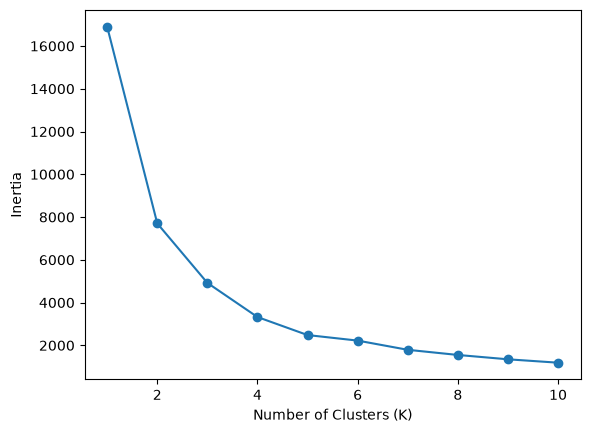

In [75]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

---
Model Training: Silhouette Score
---

In [82]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = list(range(2, 11))

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f'k={k}: silhouette score = {score:.4f}')

k=2: silhouette score = 0.4812
k=3: silhouette score = 0.4513
k=4: silhouette score = 0.4709
k=5: silhouette score = 0.4433
k=6: silhouette score = 0.4405
k=7: silhouette score = 0.4320
k=8: silhouette score = 0.4277
k=9: silhouette score = 0.4278
k=10: silhouette score = 0.4345


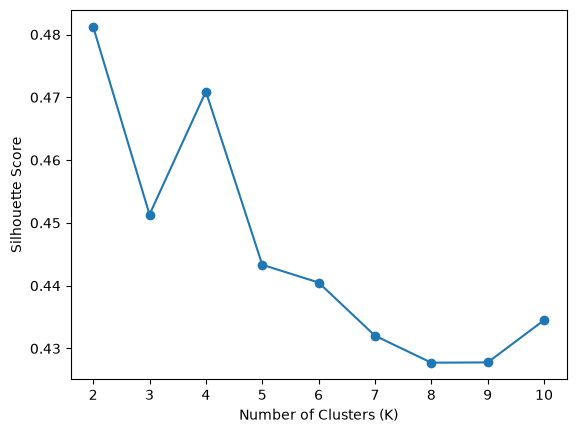

In [83]:
plt.plot(list(k_range_sil), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_sil))
plt.show()

---
Model Training: Choosing K
---

In [94]:
print('k2 - k3:', inertia_values[k_range.index(2)] - inertia_values[k_range.index(3)])
print('k3 - k4:', inertia_values[k_range.index(3)] - inertia_values[k_range.index(4)])
print('k4 - k5:', inertia_values[k_range.index(4)] - inertia_values[k_range.index(5)])
print('k5 - k6:', inertia_values[k_range.index(5)] - inertia_values[k_range.index(6)])
print('k6 - k7:', inertia_values[k_range.index(6)] - inertia_values[k_range.index(7)])

k2 - k3: 2781.312737225745
k3 - k4: 1596.9859844919142
k4 - k5: 843.1265793473267
k5 - k6: 258.9090196173206
k6 - k7: 430.7471767149034


In [89]:
print('k2 - k3:', silhouette_scores[k_range_sil.index(2)] - silhouette_scores[k_range_sil.index(3)])
print('k3 - k4:', silhouette_scores[k_range_sil.index(3)] - silhouette_scores[k_range_sil.index(4)])
print('k4 - k5:', silhouette_scores[k_range_sil.index(4)] - silhouette_scores[k_range_sil.index(5)])

k2 - k3: 0.029916785779534827
k3 - k4: -0.019595207376194412
k4 - k5: 0.027591686131563875


In [96]:
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_cluster)

unique_k4, counts_k4 = np.unique(labels_k4, return_counts=True)
print('k=4: cluster sizes =', 
      dict(zip(unique_k4, counts_k4)))

k=4: cluster sizes = {np.int32(0): np.int64(920), np.int32(1): np.int64(1368), np.int32(2): np.int64(1550), np.int32(3): np.int64(1796)}


Difference in inertia
Silhouette scores
Imbalance in rows (no imbalance)

---
Model Training: Choosing Final K
---